In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             classification_report)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('../data/processed/clean.csv')

TARGET = 'SeriousDlqin2yrs'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

print("Features:", FEATURES)
print("Class balance:\n", y.value_counts(normalize=True))

Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'debt_to_income_ratio', 'total_past_due', 'credit_util_bucket']
Class balance:
 SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (120000, 13)
Test size: (30000, 13)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fill any remaining NaNs with median
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("NaNs remaining:", X_train.isnull().sum().sum())

Train size: (120000, 13)
Test size: (30000, 13)
NaNs remaining: 0


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_probs)
print(f"Logistic Regression ROC-AUC: {lr_auc:.4f}")

Logistic Regression ROC-AUC: 0.8344


In [7]:
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=50)

xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_probs)
print(f"\nXGBoost ROC-AUC: {xgb_auc:.4f}")

[0]	validation_0-auc:0.83333
[50]	validation_0-auc:0.86698
[100]	validation_0-auc:0.86956
[150]	validation_0-auc:0.86962
[200]	validation_0-auc:0.86916
[250]	validation_0-auc:0.86898
[299]	validation_0-auc:0.86854

XGBoost ROC-AUC: 0.8685


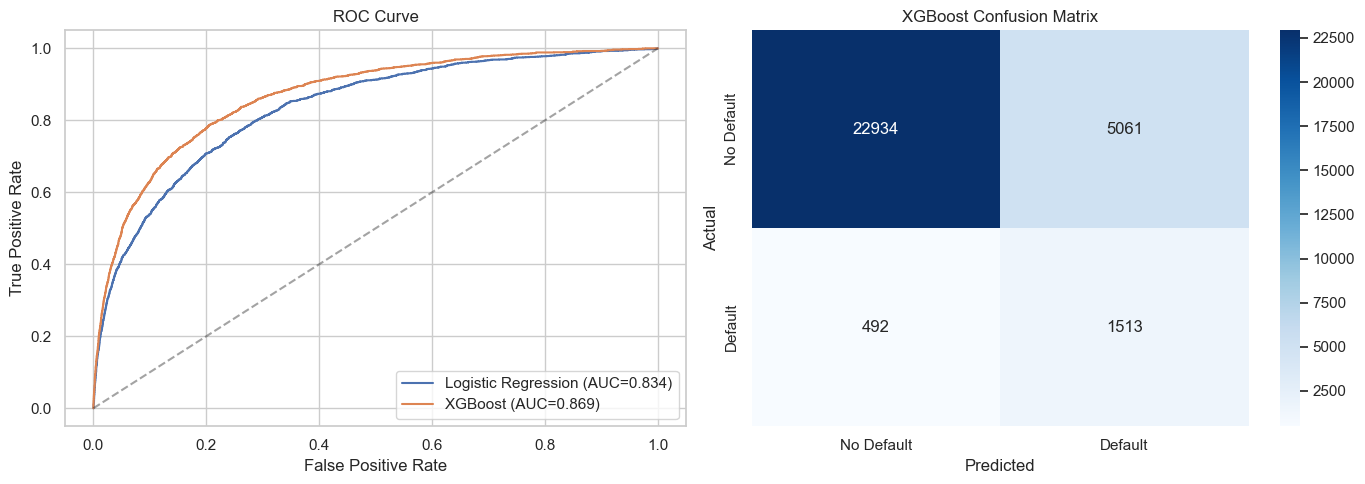


Classification Report:

              precision    recall  f1-score   support

  No Default       0.98      0.82      0.89     27995
     Default       0.23      0.75      0.35      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.79      0.62     30000
weighted avg       0.93      0.81      0.86     30000



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
for name, probs in [('Logistic Regression', lr_probs), ('XGBoost', xgb_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Confusion matrix for XGBoost
xgb_preds = xgb.predict(X_test)
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'], ax=axes[1])
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../reports/model_performance.png', dpi=150)
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_preds, target_names=['No Default','Default']))

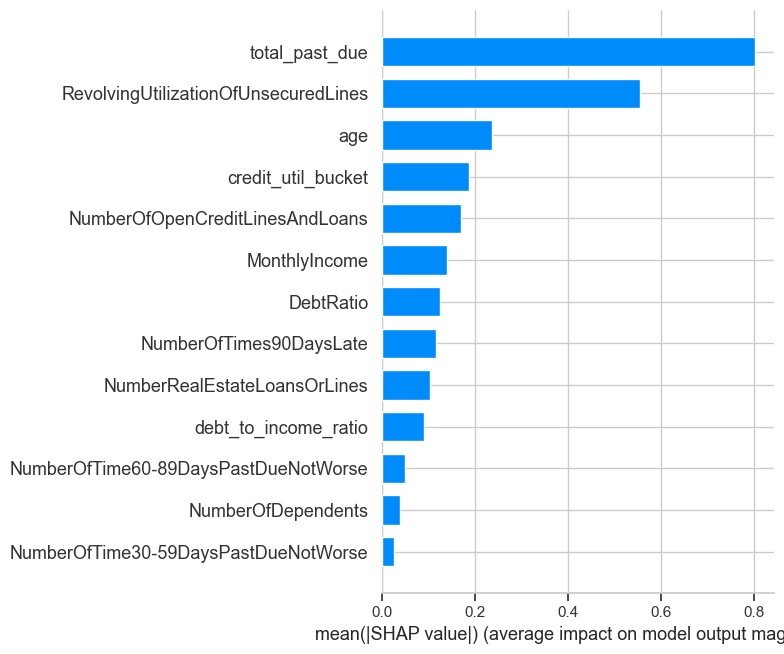

In [9]:
explainer    = shap.TreeExplainer(xgb)
shap_values  = explainer.shap_values(X_test)

# Global bar plot
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../reports/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

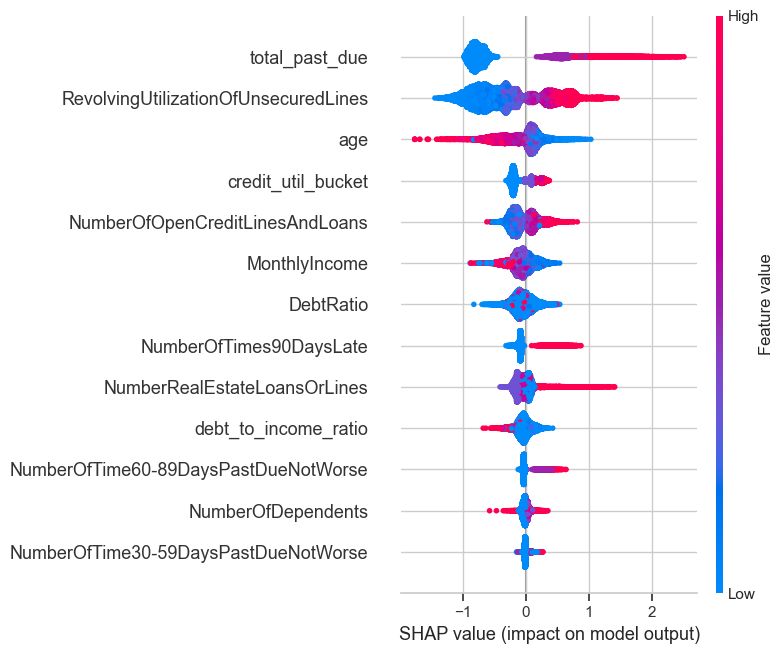

In [10]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../reports/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

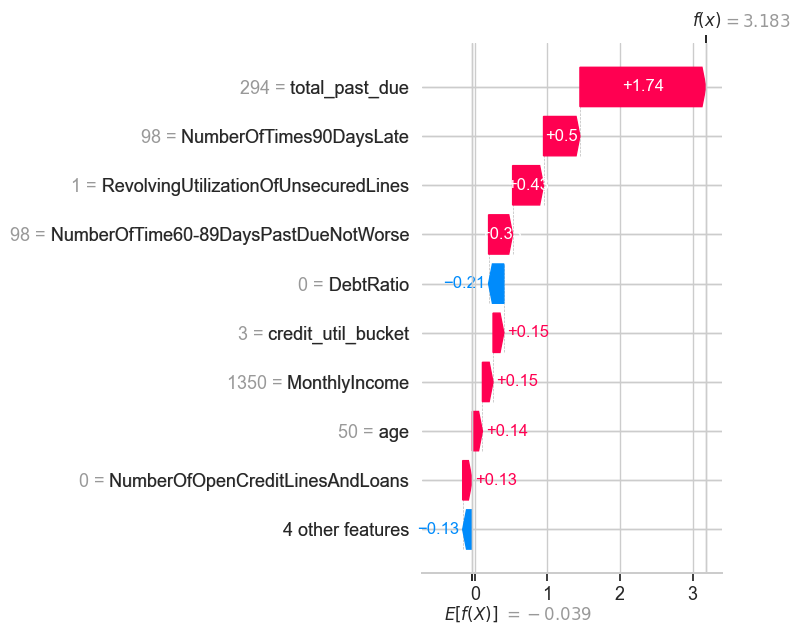

In [11]:
# Pick one high-risk customer from test set
high_risk_idx = y_test[y_test == 1].index[0]
row_position  = X_test.index.get_loc(high_risk_idx)

shap.plots.waterfall(
    shap.Explanation(
        values        = shap_values[row_position],
        base_values   = explainer.expected_value,
        data          = X_test.iloc[row_position],
        feature_names = FEATURES
    ),
    show=False
)
plt.tight_layout()
plt.savefig('../reports/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
joblib.dump(xgb,     '../src/model.pkl')
joblib.dump(scaler,  '../src/scaler.pkl')
joblib.dump(FEATURES,'../src/features.pkl')

print("Saved: model.pkl, scaler.pkl, features.pkl")
print(f"\nFinal XGBoost ROC-AUC: {xgb_auc:.4f}")
print(f"Baseline LR  ROC-AUC: {lr_auc:.4f}")

Saved: model.pkl, scaler.pkl, features.pkl

Final XGBoost ROC-AUC: 0.8685
Baseline LR  ROC-AUC: 0.8344
